# Trabajo Práctico N°1 — EDA: Developer Burnout Dataset

**Alumno:** Gonzalo Zarazaga

---
## Dataset: Developer Burnout Prediction

### Descripción
El dataset modela patrones de trabajo, niveles de estrés y riesgo de burnout en developers, a partir de factores de estilo de vida y productividad. Captura relaciones realistas entre carga laboral, hábitos de salud y estrés mental.

### Diccionario de datos

| Variable | Descripción |
|---|---|
| `age` | Edad del developer |
| `experience_years` | Años de experiencia |
| `daily_work_hours` | Horas de trabajo por día |
| `sleep_hours` | Horas de sueño por día |
| `caffeine_intake` | Tazas de café por día |
| `bugs_per_day` | Bugs generados por día |
| `commits_per_day` | Commits de Git por día |
| `meetings_per_day` | Reuniones por día |
| `screen_time` | Tiempo total frente a pantalla (horas) |
| `exercise_hours` | Actividad física diaria (horas) |
| `stress_level` | Puntaje de estrés (0–100) |
| `burnout_level` | Variable objetivo: *Low*, *Medium*, *High* |

### Características
- 7.000 filas · 12 columnas
- ~2% de valores faltantes
- Dependencias realistas entre features
- Apto para clasificación y análisis exploratorio

**Fuente:** [Kaggle — Developer Burnout Prediction Dataset (7000 samples)](https://www.kaggle.com/datasets/asifxzaman/developer-burnout-prediction-dataset7000-samples)


### Hipótesis de análisis

Las siguientes hipótesis guían el análisis exploratorio del dataset:

- **H1 — Estrés y burnout:** A mayor `stress_level`, mayor nivel de `burnout_level`. Se espera que los developers con burnout *High* presenten niveles de estrés significativamente más altos que los de nivel *Low*.

- **H2 — Horas de trabajo y estrés:** A mayor cantidad de horas trabajadas por día (`daily_work_hours`), mayor nivel de estrés (`stress_level`). Trabajar más horas debería correlacionar positivamente con el estrés.

- **H3 — Ejercicio como factor protector:** Los developers que realizan más actividad física (`exercise_hours`) presentan menor nivel de estrés y burnout. El ejercicio actuaría como factor protector contra el agotamiento.

- **H4 — Reuniones y estrés:** A mayor cantidad de reuniones por día (`meetings_per_day`), mayor nivel de estrés (`stress_level`). Las interrupciones y el overhead de comunicación contribuyen al agotamiento.


## Exploración inicial del dataset

Se realiza una inspección general del dataset para entender su estructura, tipos de datos, rangos y valores únicos antes de cualquier transformación.


In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_developer_burnout_dataset = pd.read_csv("data/developer_burnout_dataset_7000.csv")
df_developer_burnout_dataset.shape #muestra cantidad de filas y columnas

(7000, 12)

In [63]:
df_developer_burnout_dataset.head()

,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level,burnout_level
0,26.0,12.0,10.33,4.45,2.0,11.0,4.0,1.0,15.07,0.14,55.96,Medium
1,39.0,10.0,8.62,5.77,5.0,15.0,11.0,5.0,13.25,0.54,82.22,High
2,34.0,13.0,NaN,4.03,5.0,2.0,18.0,9.0,11.18,1.54,61.77,Medium
3,30.0,1.0,6.85,6.47,2.0,15.0,26.0,1.0,11.14,0.96,54.98,Medium
4,27.0,7.0,4.24,5.80,NaN,9.0,17.0,7.0,8.05,0.36,27.90,Low


In [64]:
df_developer_burnout_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               6860 non-null   float64
 1   experience_years  6860 non-null   float64
 2   daily_work_hours  6860 non-null   float64
 3   sleep_hours       6860 non-null   float64
 4   caffeine_intake   6860 non-null   float64
 5   bugs_per_day      6860 non-null   float64
 6   commits_per_day   6860 non-null   float64
 7   meetings_per_day  6860 non-null   float64
 8   screen_time       6860 non-null   float64
 9   exercise_hours    6860 non-null   float64
 10  stress_level      6860 non-null   float64
 11  burnout_level     6860 non-null   object 
dtypes: float64(11), object(1)
memory usage: 656.4+ KB


In [65]:
df_developer_burnout_dataset.nunique()

age                   25
experience_years      20
daily_work_hours     999
sleep_hours          501
caffeine_intake        8
bugs_per_day          20
commits_per_day       30
meetings_per_day      10
screen_time         1279
exercise_hours       201
stress_level        4554
burnout_level          3
dtype: int64

In [66]:
df_developer_burnout_dataset.burnout_level.unique()

array(['Medium', 'High', 'Low', nan], dtype=object)

In [67]:
df_developer_burnout_dataset.caffeine_intake.unique()

array([ 2.,  5., nan,  0.,  6.,  4.,  3.,  7.,  1.])

In [68]:
df_developer_burnout_dataset.daily_work_hours.min()

4.0

In [69]:
df_developer_burnout_dataset.daily_work_hours.max()

14.0

In [70]:
df_developer_burnout_dataset.sleep_hours.min()

4.0

In [71]:
df_developer_burnout_dataset.sleep_hours.max()

9.0

In [72]:
df_developer_burnout_dataset.screen_time.min()

5.21

In [73]:
df_developer_burnout_dataset.screen_time.max()

18.93

In [74]:
df_developer_burnout_dataset.describe()

,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level
count,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000
mean,32.129446,9.581050,9.000277,6.485638,3.540671,9.482653,14.458455,4.545044,11.974773,1.007611,53.652825
std,7.230254,5.760972,2.863944,1.445008,2.283445,5.751664,8.669846,2.856766,3.091204,0.576708,23.446656
min,20.000000,0.000000,4.000000,4.000000,0.000000,0.000000,0.000000,0.000000,5.210000,0.000000,0.000000
25%,26.000000,5.000000,6.560000,5.220000,2.000000,5.000000,7.000000,2.000000,9.460000,0.510000,36.587500
50%,32.000000,10.000000,8.990000,6.460000,4.000000,9.000000,14.000000,5.000000,12.020000,1.020000,53.795000
75%,38.000000,15.000000,11.422500,7.740000,6.000000,14.000000,22.000000,7.000000,14.422500,1.510000,70.800000
max,44.000000,19.000000,14.000000,9.000000,7.000000,19.000000,29.000000,9.000000,18.930000,2.000000,100.000000


## Tipos de variables

| Variable | Tipo | Descripción |
|---|---|---|
| `age` | Numérica discreta | Edad del developer (20–44, valores enteros) |
| `experience_years` | Numérica discreta | Años de experiencia (0–19, valores enteros) |
| `caffeine_intake` | Numérica discreta | Tazas de café por día (0–7, valores enteros) |
| `bugs_per_day` | Numérica discreta | Bugs generados por día (0–19) |
| `commits_per_day` | Numérica discreta | Commits por día (0–29) |
| `meetings_per_day` | Numérica discreta | Reuniones por día (0–9) |
| `daily_work_hours` | Numérica continua | Horas de trabajo por día (4–14) |
| `sleep_hours` | Numérica continua | Horas de sueño por día (4–9) |
| `screen_time` | Numérica continua | Tiempo de pantalla en horas (5–19) |
| `exercise_hours` | Numérica continua | Actividad física diaria en horas (0–2) |
| `stress_level` | Numérica continua | Puntaje de estrés (0–100) |
| `burnout_level` | **Categórica ordinal** | Variable objetivo: *Low* < *Medium* < *High* |


## Limpieza de datos

El dataset presenta **140 valores nulos por columna**, distribuidos en **1.510 filas** con al menos un campo vacío:

| Nulos por fila | Filas |
|:-:|:-:|
| 0 (sin nulos) | 5.490 |
| 1 nulo | 1.352 |
| 2 nulos | 146 |
| 3 nulos | 12 |

Como los nulos están dispersos en distintas filas, eliminar todas las filas afectadas implicaría perder el **~22% del dataset**, lo cual no es razonable.

**Estrategia adoptada:**
- Filas donde `burnout_level` es nulo → **eliminar** (no se puede imputar la variable objetivo)
- Nulos en columnas numéricas → **imputar con la mediana** de cada columna (más robusta que la media frente a valores atípicos)


In [75]:
print("Estado inicial:")
print(f"  Filas: {df_developer_burnout_dataset.shape[0]}")
#suma de todas las filas que tienen al menos un valor nulos
print(f"  Filas con al menos un nulo: {df_developer_burnout_dataset.isna().any(axis=1).sum()}")
#Ordena las filas por cantidad de nulos y muestra la distribucion de los valores nulos
print(f"  Distribución de nulos por fila:")
print(df_developer_burnout_dataset.isna().sum(axis=1).value_counts().sort_index())

# Eliminar filas donde la variable objetivo es nula
df_developer_burnout_dataset = df_developer_burnout_dataset.dropna(subset=["burnout_level"])

# Imputar nulos en columnas numéricas con la mediana
# Obtiene las filas numericas
columnas_numericas = df_developer_burnout_dataset.select_dtypes(include="number").columns
# Completa los valores nulos de cada columna con la mediana de esa misma columna 
df_developer_burnout_dataset[columnas_numericas] = df_developer_burnout_dataset[columnas_numericas].fillna(df_developer_burnout_dataset[columnas_numericas].median()
)

print("\nEstado final:")
print(f"  Filas: {df_developer_burnout_dataset.shape[0]}")
print(f"  Valores nulos restantes: {df_developer_burnout_dataset.isna().sum().sum()}")


Estado inicial:
  Filas: 7000
  Filas con al menos un nulo: 1510
  Distribución de nulos por fila:
0    5490
1    1352
2     146
3      12
Name: count, dtype: int64

Estado final:
  Filas: 6860
  Valores nulos restantes: 0


## Detección de valores atípicos

Se utiliza el método **IQR (Rango Intercuartílico)** para detectar outliers en las variables numéricas.
Un valor se considera atípico si cae fuera del rango:

```
límite inferior = Q1 - 1.5 × IQR
límite superior = Q3 + 1.5 × IQR
```

Este método es más robusto que el Z-score porque no asume distribución normal.


In [76]:
columnas_numericas = df_developer_burnout_dataset.select_dtypes(include="number").columns

resumen_outliers = []

for col in columnas_numericas:
    Q1 = df_developer_burnout_dataset[col].quantile(0.25)
    Q3 = df_developer_burnout_dataset[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR

    outliers = df_developer_burnout_dataset[
        (df_developer_burnout_dataset[col] < limite_inf) |
        (df_developer_burnout_dataset[col] > limite_sup)
    ]

    resumen_outliers.append({
        "Variable": col,
        "Q1": round(Q1, 2),
        "Q3": round(Q3, 2),
        "IQR": round(IQR, 2),
        "Límite inferior": round(limite_inf, 2),
        "Límite superior": round(limite_sup, 2),
        "Cantidad de outliers": len(outliers),
        "% del total": round(len(outliers) / len(df_developer_burnout_dataset) * 100, 2)
    })

df_outliers = pd.DataFrame(resumen_outliers)
df_outliers


,Variable,Q1,Q3,IQR,Límite inferior,Límite superior,Cantidad de outliers,% del total
0,age,26.00,38.00,12.00,8.00,56.00,0,0.0
1,experience_years,5.00,15.00,10.00,-10.00,30.00,0,0.0
2,daily_work_hours,6.58,11.36,4.78,-0.59,18.54,0,0.0
3,sleep_hours,5.25,7.71,2.46,1.56,11.40,0,0.0
4,caffeine_intake,2.00,6.00,4.00,-4.00,12.00,0,0.0
5,bugs_per_day,5.00,14.00,9.00,-8.50,27.50,0,0.0
6,commits_per_day,7.00,22.00,15.00,-15.50,44.50,0,0.0
7,meetings_per_day,2.00,7.00,5.00,-5.50,14.50,0,0.0
8,screen_time,9.51,14.36,4.85,2.24,21.64,0,0.0
9,exercise_hours,0.52,1.49,0.97,-0.94,2.94,0,0.0


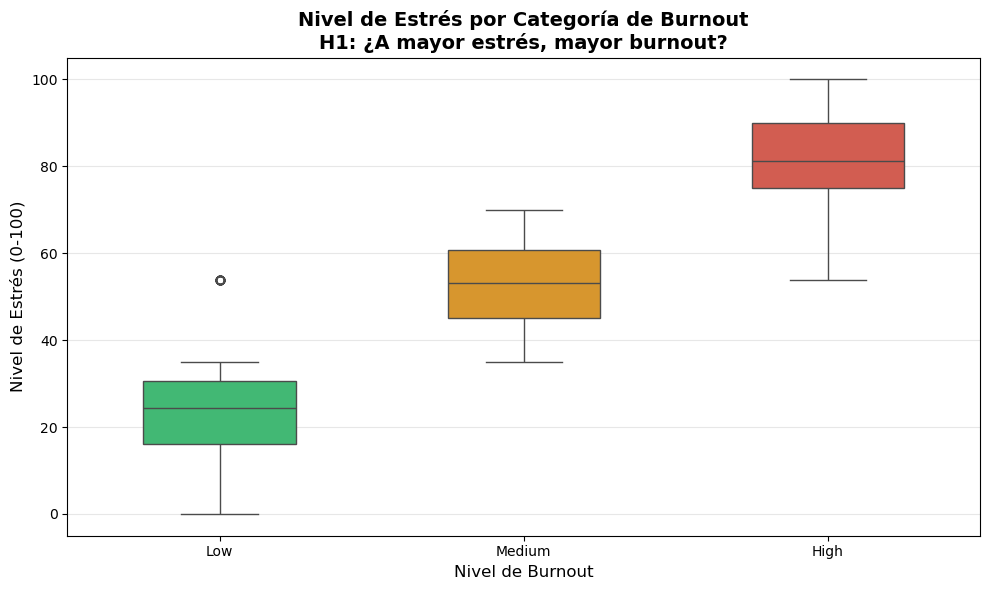

In [77]:
# H1: comparación del nivel de estrés entre categorías de burnout — los bigotes muestran outliers por grupo
palette = {"Low": "#2ecc71", "Medium": "#f39c12", "High": "#e74c3c"}

fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df_developer_burnout_dataset,
    x="burnout_level",
    y="stress_level",
    order=["Low", "Medium", "High"],
    palette=palette,
    hue="burnout_level",
    legend=False,
    width=0.5,
    ax=ax
)

ax.set_title(
    "Nivel de Estrés por Categoría de Burnout\n"
    "H1: ¿A mayor estrés, mayor burnout?",
    fontsize=14, fontweight="bold"
)
ax.set_xlabel("Nivel de Burnout", fontsize=12)
ax.set_ylabel("Nivel de Estrés (0-100)", fontsize=12)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


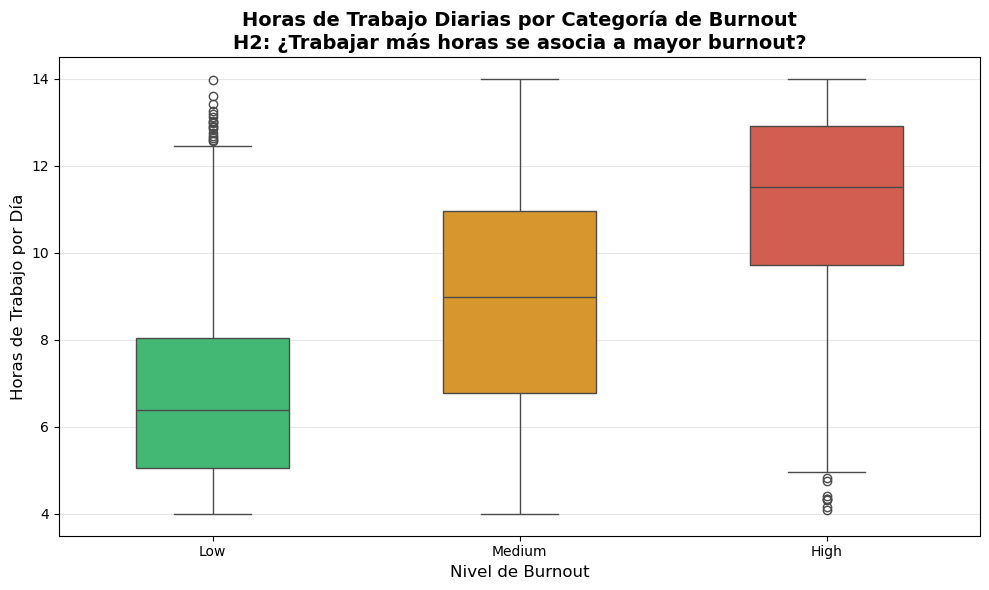

In [78]:
# H2: comparación de horas trabajadas entre categorías de burnout
palette = {"Low": "#2ecc71", "Medium": "#f39c12", "High": "#e74c3c"}

fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df_developer_burnout_dataset,
    x="burnout_level",
    y="daily_work_hours",
    order=["Low", "Medium", "High"],
    palette=palette,
    hue="burnout_level",
    legend=False,
    width=0.5,
    ax=ax
)

ax.set_title(
    "Horas de Trabajo Diarias por Categoría de Burnout\n"
    "H2: ¿Trabajar más horas se asocia a mayor burnout?",
    fontsize=14, fontweight="bold"
)
ax.set_xlabel("Nivel de Burnout", fontsize=12)
ax.set_ylabel("Horas de Trabajo por Día", fontsize=12)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


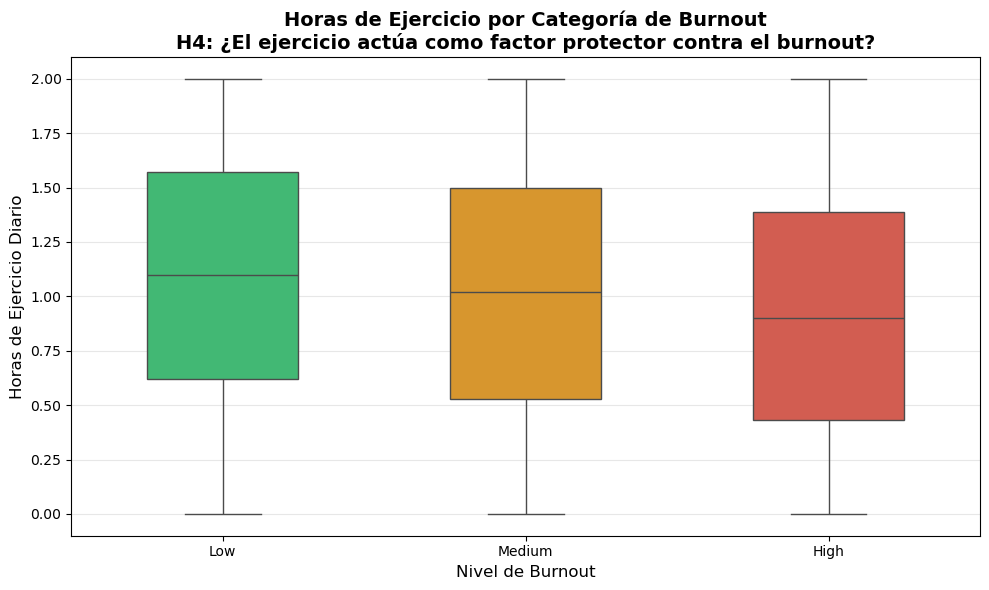

In [79]:
# H4: comparación de horas de ejercicio entre categorías de burnout — ¿los que más se ejercitan tienen menos burnout?
palette = {"Low": "#2ecc71", "Medium": "#f39c12", "High": "#e74c3c"}

fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df_developer_burnout_dataset,
    x="burnout_level",
    y="exercise_hours",
    order=["Low", "Medium", "High"],
    palette=palette,
    hue="burnout_level",
    legend=False,
    width=0.5,
    ax=ax
)

ax.set_title(
    "Horas de Ejercicio por Categoría de Burnout\n"
    "H4: ¿El ejercicio actúa como factor protector contra el burnout?",
    fontsize=14, fontweight="bold"
)
ax.set_xlabel("Nivel de Burnout", fontsize=12)
ax.set_ylabel("Horas de Ejercicio Diario", fontsize=12)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


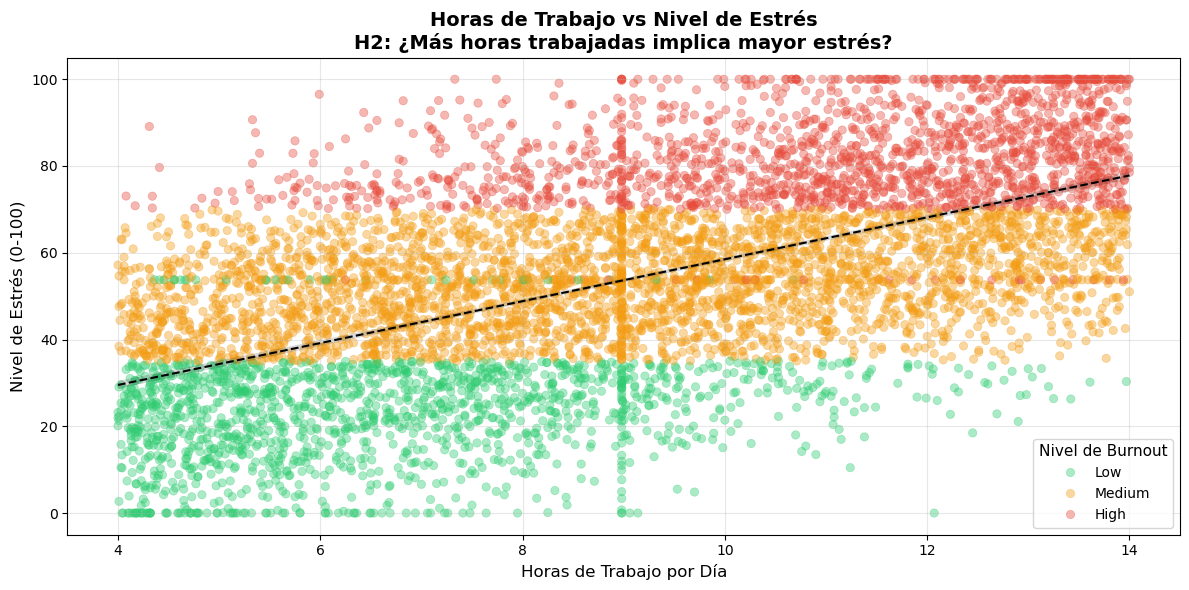

In [80]:
# H2: relación entre horas trabajadas y nivel de estrés — se espera correlación positiva
palette = {"Low": "#2ecc71", "Medium": "#f39c12", "High": "#e74c3c"}

fig, ax = plt.subplots(figsize=(12, 6))

sns.scatterplot(
    data=df_developer_burnout_dataset,
    x="daily_work_hours",
    y="stress_level",
    hue="burnout_level",
    hue_order=["Low", "Medium", "High"],
    palette=palette,
    alpha=0.4,
    edgecolor=None,
    ax=ax
)

# Línea de tendencia general para visualizar la correlación
sns.regplot(
    data=df_developer_burnout_dataset,
    x="daily_work_hours",
    y="stress_level",
    scatter=False,
    color="black",
    line_kws={"linewidth": 1.5, "linestyle": "--", "label": "Tendencia general"},
    ax=ax
)

ax.set_title(
    "Horas de Trabajo vs Nivel de Estrés\n"
    "H2: ¿Más horas trabajadas implica mayor estrés?",
    fontsize=14, fontweight="bold"
)
ax.set_xlabel("Horas de Trabajo por Día", fontsize=12)
ax.set_ylabel("Nivel de Estrés (0-100)", fontsize=12)
ax.legend(title="Nivel de Burnout", title_fontsize=11, fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


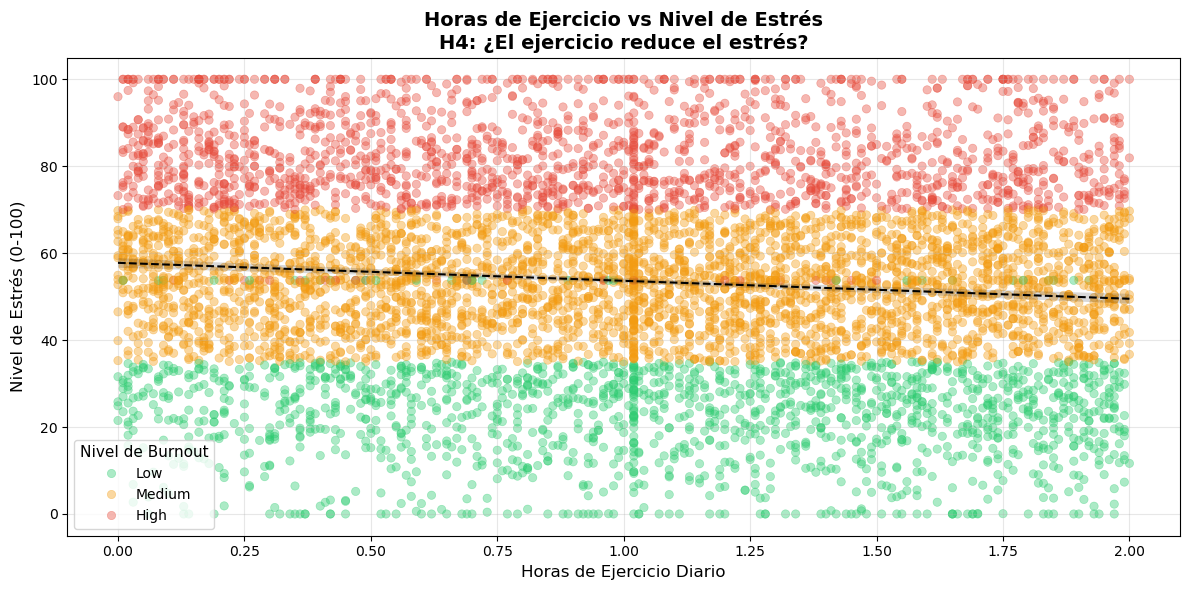

In [81]:
# H4: relación entre ejercicio y estrés — se espera correlación negativa si el ejercicio es factor protector
palette = {"Low": "#2ecc71", "Medium": "#f39c12", "High": "#e74c3c"}

fig, ax = plt.subplots(figsize=(12, 6))

sns.scatterplot(
    data=df_developer_burnout_dataset,
    x="exercise_hours",
    y="stress_level",
    hue="burnout_level",
    hue_order=["Low", "Medium", "High"],
    palette=palette,
    alpha=0.4,
    edgecolor=None,
    ax=ax
)

# Línea de tendencia general para visualizar la correlación
sns.regplot(
    data=df_developer_burnout_dataset,
    x="exercise_hours",
    y="stress_level",
    scatter=False,
    color="black",
    line_kws={"linewidth": 1.5, "linestyle": "--", "label": "Tendencia general"},
    ax=ax
)

ax.set_title(
    "Horas de Ejercicio vs Nivel de Estrés\n"
    "H4: ¿El ejercicio reduce el estrés?",
    fontsize=14, fontweight="bold"
)
ax.set_xlabel("Horas de Ejercicio Diario", fontsize=12)
ax.set_ylabel("Nivel de Estrés (0-100)", fontsize=12)
ax.legend(title="Nivel de Burnout", title_fontsize=11, fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


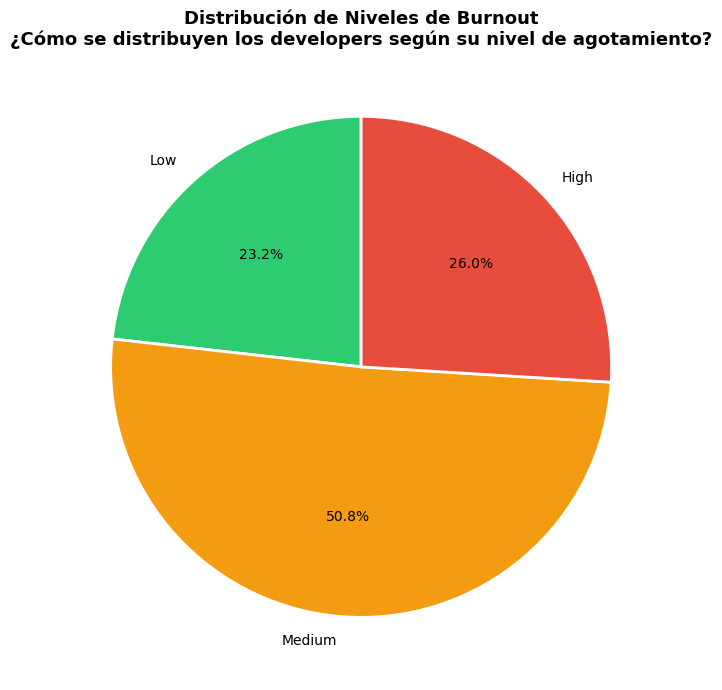

In [82]:
# Distribución de la variable objetivo — punto de partida del análisis
palette = {"Low": "#2ecc71", "Medium": "#f39c12", "High": "#e74c3c"}

fig, ax = plt.subplots(figsize=(7, 7))

conteo = df_developer_burnout_dataset["burnout_level"].value_counts().reindex(["Low", "Medium", "High"])

ax.pie(
    conteo,
    labels=conteo.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=[palette[k] for k in conteo.index],
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)

ax.set_title(
    "Distribución de Niveles de Burnout\n"
    "¿Cómo se distribuyen los developers según su nivel de agotamiento?",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()


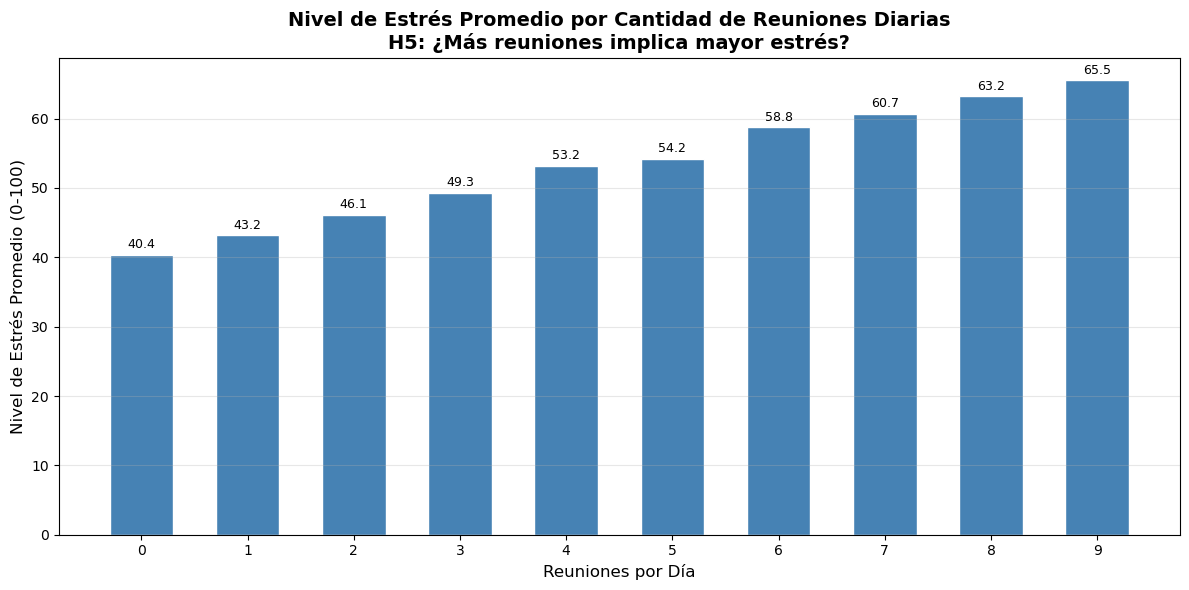

In [83]:
# H5: nivel de estrés promedio según cantidad de reuniones diarias
stress_por_reuniones = (
    df_developer_burnout_dataset
    .groupby("meetings_per_day")["stress_level"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(
    stress_por_reuniones["meetings_per_day"],
    stress_por_reuniones["stress_level"],
    color="steelblue",
    edgecolor="white",
    width=0.6
)

# Etiqueta con el valor encima de cada barra
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{bar.get_height():.1f}",
        ha="center", va="bottom", fontsize=9
    )

ax.set_title(
    "Nivel de Estrés Promedio por Cantidad de Reuniones Diarias\n"
    "H5: ¿Más reuniones implica mayor estrés?",
    fontsize=14, fontweight="bold"
)
ax.set_xlabel("Reuniones por Día", fontsize=12)
ax.set_ylabel("Nivel de Estrés Promedio (0-100)", fontsize=12)
ax.set_xticks(stress_por_reuniones["meetings_per_day"])
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


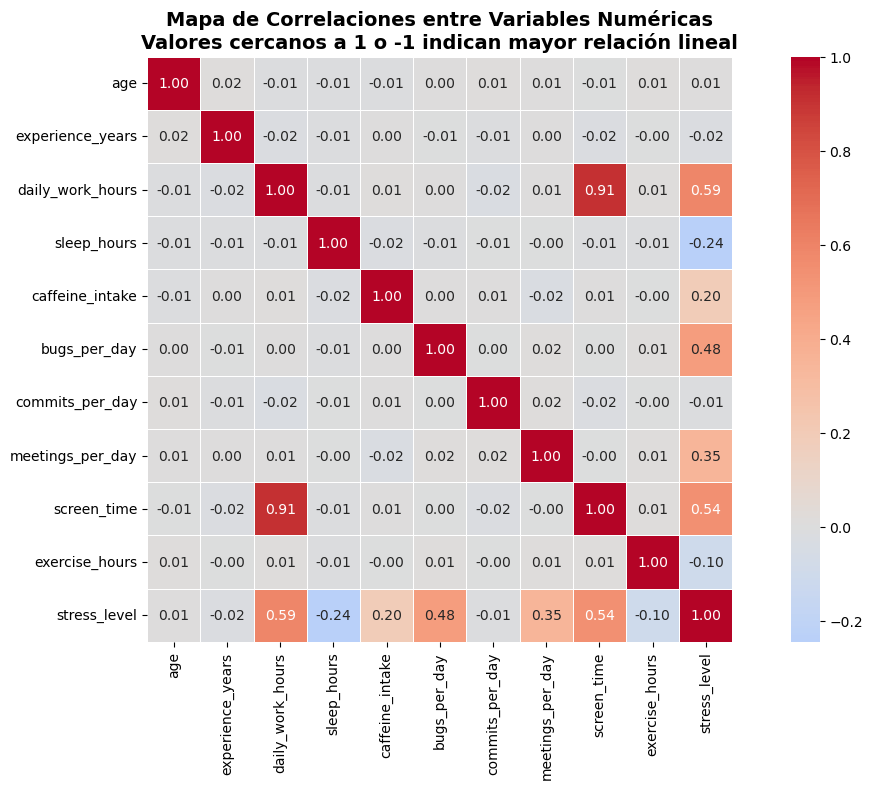

In [84]:
# Mapa de correlaciones entre variables numéricas — identifica relaciones lineales entre features
fig, ax = plt.subplots(figsize=(12, 8))

correlaciones = df_developer_burnout_dataset.select_dtypes(include="number").corr()

sns.heatmap(
    correlaciones,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True,
    ax=ax
)

ax.set_title(
    "Mapa de Correlaciones entre Variables Numéricas\n"
    "Valores cercanos a 1 o -1 indican mayor relación lineal",
    fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.show()

# daily_work_hours ↔ screen_time = 0.91 — correlación muy fuerte: quien trabaja más horas 
# pasa más tiempo en pantalla. Casi redundantes.
# daily_work_hours ↔ stress_level = 0.59 — confirma H2: más horas → más estrés
# screen_time ↔ stress_level = 0.54 — el tiempo de pantalla también predice estrés
# bugs_per_day ↔ stress_level = 0.48 — generar más bugs se asocia a mayor estrés
# sleep_hours ↔ stress_level = -0.25 — negativa: dormir más se asocia a menos estrés
# exercise_hours ↔ stress_level = -0.10 — negativa débil, confirma H4 parcialmente

# La mayoría de los pares tienen correlación cercana a 0 (blanco), lo que indica que 
# las variables son bastante independientes entre sí, salvo las relacionadas con el estrés.

## Visualizaciones

Se presentan las visualizaciones del análisis exploratorio organizadas por tipo: histogramas con KDE para analizar distribuciones, boxplots para detectar outliers por grupo y gráficos adicionales para explorar relaciones y proporciones.


In [85]:

#Las distribuciones de stress_level por grupo presentan una forma aproximadamente normal,
# con picos centrales bien definidos y colas simétricas. Deberia hacerse un analisis mas detallado aplicando un test 
# como por ejemplo Shapiro.


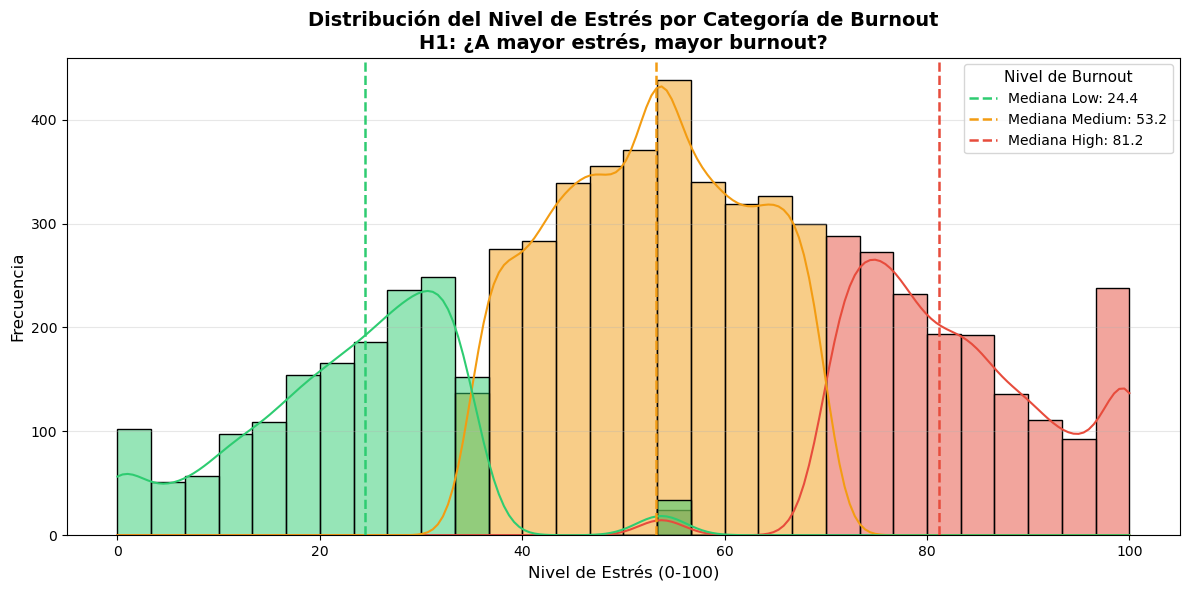

In [86]:
# H1: distribución de stress_level por categoría de burnout — se espera separación clara entre grupos
palette = {"Low": "#2ecc71", "Medium": "#f39c12", "High": "#e74c3c"}

fig, ax = plt.subplots(figsize=(12, 6))

sns.histplot(
    data=df_developer_burnout_dataset,
    x="stress_level",
    hue="burnout_level",
    hue_order=["Low", "Medium", "High"],
    kde=True,
    palette=palette,
    alpha=0.5,
    bins=30,
    ax=ax
)

for level, color in palette.items():
    mediana = df_developer_burnout_dataset[
        df_developer_burnout_dataset["burnout_level"] == level
    ]["stress_level"].median()
    ax.axvline(mediana, color=color, linestyle="--", linewidth=1.8,
               label=f"Mediana {level}: {mediana:.1f}")

ax.set_title(
    "Distribución del Nivel de Estrés por Categoría de Burnout\n"
    "H1: ¿A mayor estrés, mayor burnout?",
    fontsize=14, fontweight="bold"
)
ax.set_xlabel("Nivel de Estrés (0-100)", fontsize=12)
ax.set_ylabel("Frecuencia", fontsize=12)
ax.legend(title="Nivel de Burnout", title_fontsize=11, fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Las distribuciones presentan forma aproximadamente normal con picos bien separados
# y escaso solapamiento entre grupos: Low ~24, Medium ~53, High ~81

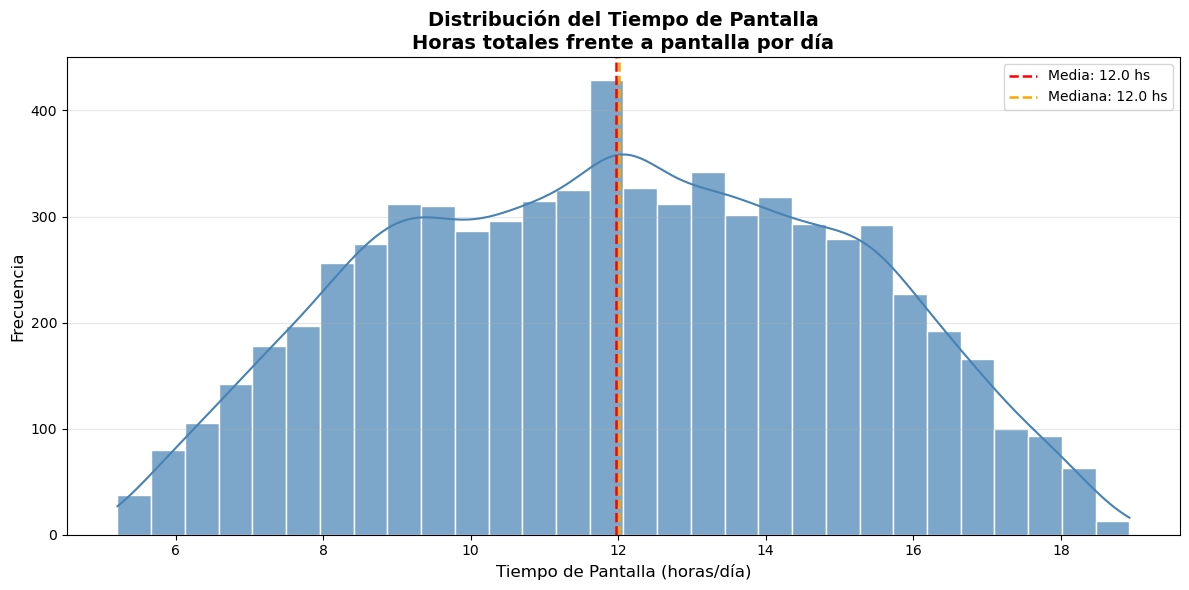

In [87]:
# Distribución general del tiempo de pantalla — sin segmentar por burnout para ver el
# comportamiento global
fig, ax = plt.subplots(figsize=(12, 6))

sns.histplot(
    data=df_developer_burnout_dataset,
    x="screen_time",
    kde=True,
    color="steelblue",
    edgecolor="white",
    alpha=0.7,
    bins=30,
    ax=ax
)

media = df_developer_burnout_dataset["screen_time"].mean()
mediana = df_developer_burnout_dataset["screen_time"].median()
ax.axvline(media, color="red", linestyle="--", linewidth=1.8, label=f"Media: {media:.1f} hs")
ax.axvline(mediana, color="orange", linestyle="--", linewidth=1.8, label=f"Mediana: {mediana:.1f} hs")

ax.set_title(
    "Distribución del Tiempo de Pantalla\n"
    "Horas totales frente a pantalla por día",
    fontsize=14, fontweight="bold"
)
ax.set_xlabel("Tiempo de Pantalla (horas/día)", fontsize=12)
ax.set_ylabel("Frecuencia", fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


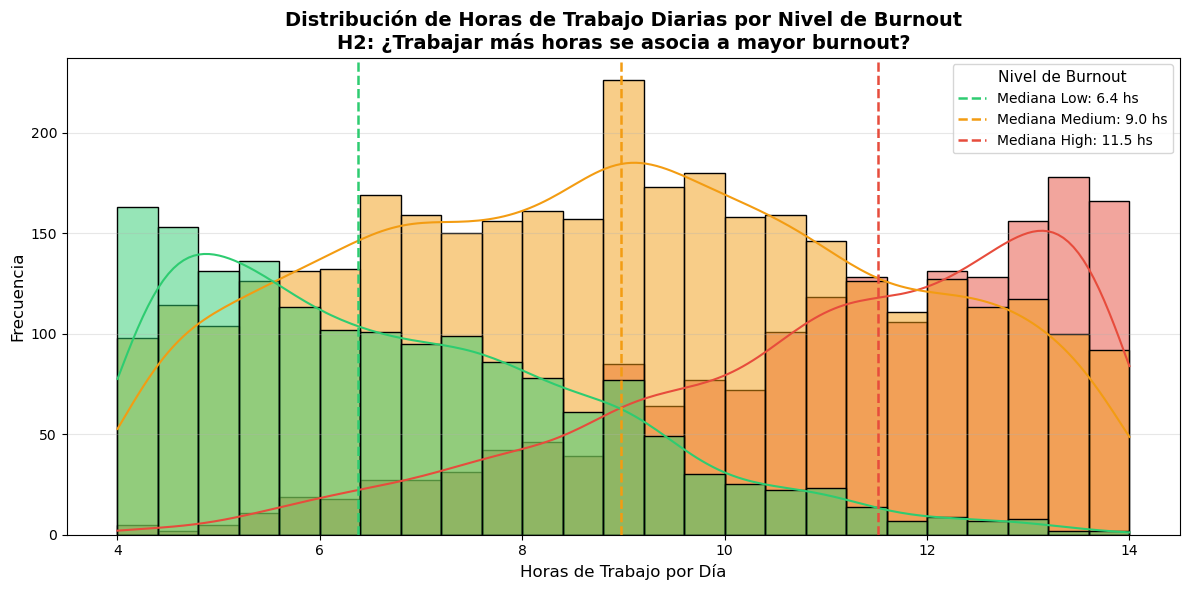

In [88]:
# H2: distribución de horas trabajadas por categoría de burnout
palette = {"Low": "#2ecc71", "Medium": "#f39c12", "High": "#e74c3c"}

fig, ax = plt.subplots(figsize=(12, 6))

sns.histplot(
    data=df_developer_burnout_dataset,
    x="daily_work_hours",
    hue="burnout_level",
    hue_order=["Low", "Medium", "High"],
    kde=True,
    palette=palette,
    alpha=0.5,
    bins=25,
    ax=ax
)

for level, color in palette.items():
    mediana = df_developer_burnout_dataset[
        df_developer_burnout_dataset["burnout_level"] == level
    ]["daily_work_hours"].median()
    ax.axvline(mediana, color=color, linestyle="--", linewidth=1.8,
               label=f"Mediana {level}: {mediana:.1f} hs")

ax.set_title(
    "Distribución de Horas de Trabajo Diarias por Nivel de Burnout\n"
    "H2: ¿Trabajar más horas se asocia a mayor burnout?",
    fontsize=14, fontweight="bold"
)
ax.set_xlabel("Horas de Trabajo por Día", fontsize=12)
ax.set_ylabel("Frecuencia", fontsize=12)
ax.legend(title="Nivel de Burnout", title_fontsize=11, fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

#Hay una frontera práctica alrededor de las 10 hs
#Por encima de 10 horas diarias, High es el grupo dominante. 
# Es un umbral concreto y útil: 
# superar las 10 hs diarias se asocia fuertemente con burnout alto.

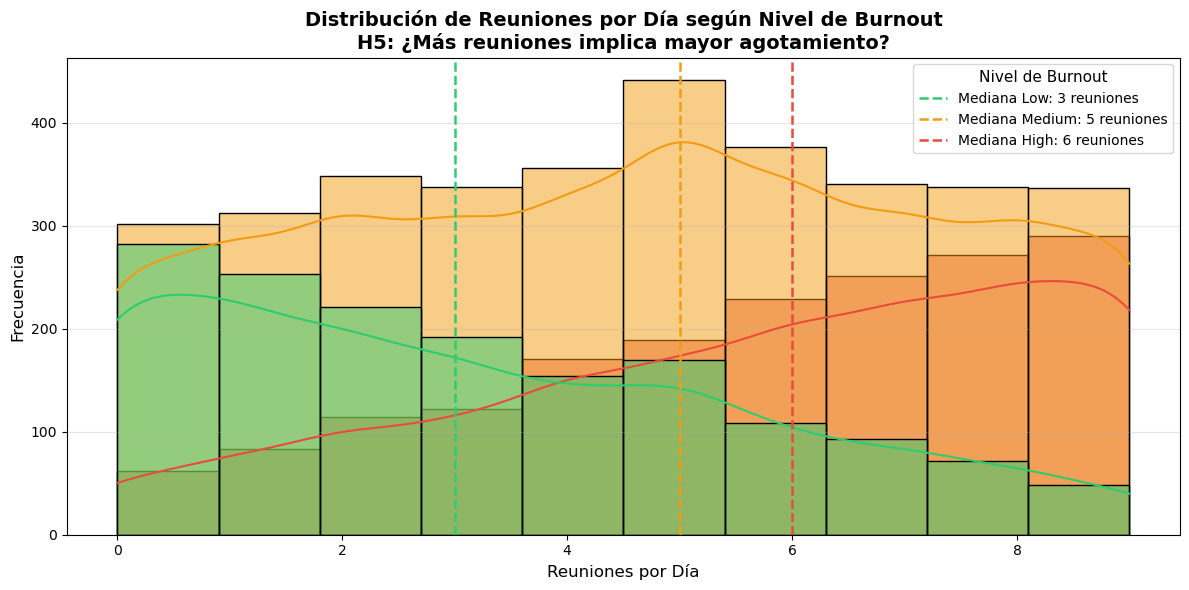

In [89]:
# H4: distribución de reuniones por día según nivel de burnout — ¿más reuniones generan más agotamiento?
palette = {"Low": "#2ecc71", "Medium": "#f39c12", "High": "#e74c3c"}

fig, ax = plt.subplots(figsize=(12, 6))

sns.histplot(
    data=df_developer_burnout_dataset,
    x="meetings_per_day",
    hue="burnout_level",
    hue_order=["Low", "Medium", "High"],
    kde=True,
    palette=palette,
    alpha=0.5,
    bins=10,
    ax=ax
)

for level, color in palette.items():
    mediana = df_developer_burnout_dataset[
        df_developer_burnout_dataset["burnout_level"] == level
    ]["meetings_per_day"].median()
    ax.axvline(mediana, color=color, linestyle="--", linewidth=1.8,
               label=f"Mediana {level}: {mediana:.0f} reuniones")

ax.set_title(
    "Distribución de Reuniones por Día según Nivel de Burnout\n"
    "H5: ¿Más reuniones implica mayor agotamiento?",
    fontsize=14, fontweight="bold"
)
ax.set_xlabel("Reuniones por Día", fontsize=12)
ax.set_ylabel("Frecuencia", fontsize=12)
ax.legend(title="Nivel de Burnout", title_fontsize=11, fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Conclusión para H4
# Confirmada pero con matices: tener pocas reuniones (≤3) se asocia claramente a burnout Low, 
# pero a partir de 5 reuniones la distinción entre Medium y High depende más de otros factores 
# como las horas trabajadas o el estrés.

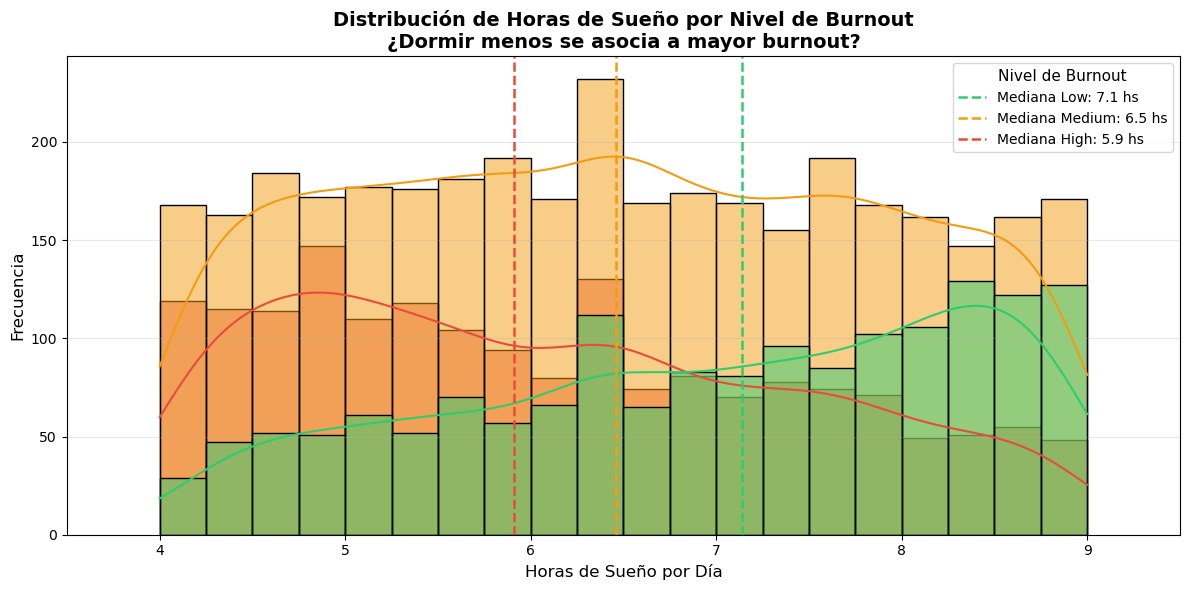

In [90]:
palette = {"Low": "#2ecc71", "Medium": "#f39c12", "High": "#e74c3c"}

fig, ax = plt.subplots(figsize=(12, 6))

sns.histplot(
    data=df_developer_burnout_dataset,
    x="sleep_hours",
    hue="burnout_level",
    hue_order=["Low", "Medium", "High"],
    kde=True,
    palette=palette,
    alpha=0.5,
    bins=20,
    ax=ax
)

# Líneas verticales con la mediana de cada grupo para facilitar la comparación
for level, color in palette.items():
    mediana = df_developer_burnout_dataset[
        df_developer_burnout_dataset["burnout_level"] == level
    ]["sleep_hours"].median()
    ax.axvline(mediana, color=color, linestyle="--", linewidth=1.8,
               label=f"Mediana {level}: {mediana:.1f} hs")

ax.set_title(
    "Distribución de Horas de Sueño por Nivel de Burnout\n"
    "¿Dormir menos se asocia a mayor burnout?",
    fontsize=14, fontweight="bold"
)
ax.set_xlabel("Horas de Sueño por Día", fontsize=12)
ax.set_ylabel("Frecuencia", fontsize=12)
ax.legend(title="Nivel de Burnout", title_fontsize=11, fontsize=10)
ax.grid(axis="y", alpha=0.3)
ax.set_xlim(df_developer_burnout_dataset["sleep_hours"].min() - 0.5,
            df_developer_burnout_dataset["sleep_hours"].max() + 0.5)
plt.tight_layout()
plt.show()

# Dormir menos se asocia a mayor burnout, pero no es un predictor fuerte. 
# Un developer que duerme 5 hs puede tener burnout Low y uno que duerme 8 hs 
# puede tener burnout High — depende más de cuántas horas trabaja y cuántas reuniones tiene.

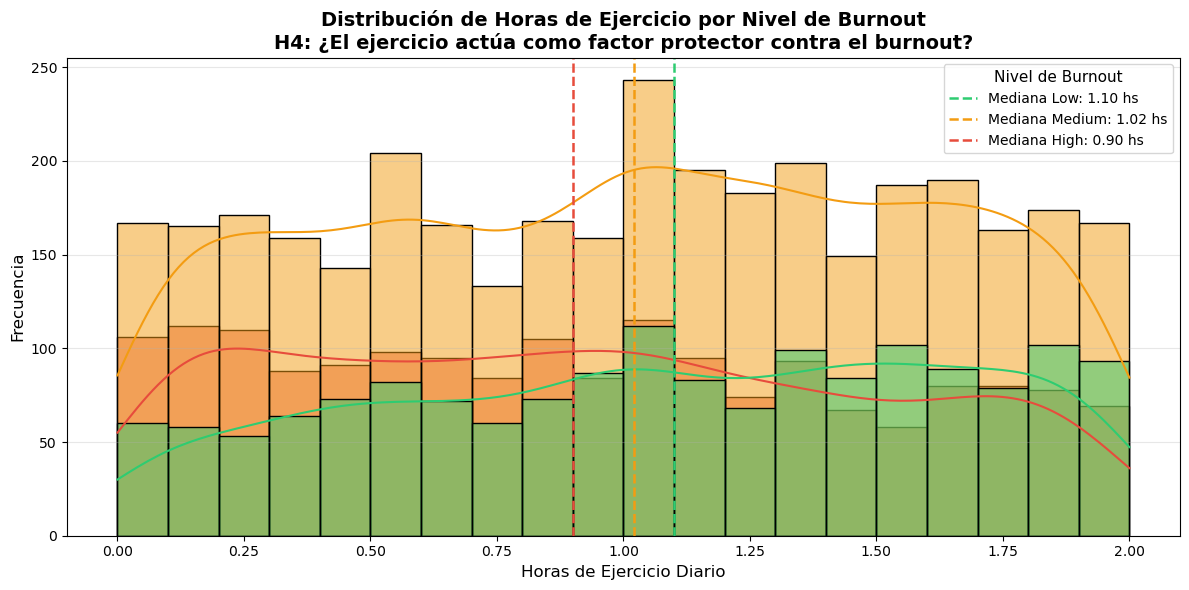

In [91]:
palette = {"Low": "#2ecc71", "Medium": "#f39c12", "High": "#e74c3c"}

fig, ax = plt.subplots(figsize=(12, 6))

sns.histplot(
    data=df_developer_burnout_dataset,
    x="exercise_hours",
    hue="burnout_level",
    hue_order=["Low", "Medium", "High"],
    kde=True,
    palette=palette,
    alpha=0.5,
    bins=20,
    ax=ax
)

# Líneas verticales con la mediana de cada grupo para facilitar la comparación
for level, color in palette.items():
    mediana = df_developer_burnout_dataset[
        df_developer_burnout_dataset["burnout_level"] == level
    ]["exercise_hours"].median()
    ax.axvline(mediana, color=color, linestyle="--", linewidth=1.8,
               label=f"Mediana {level}: {mediana:.2f} hs")

ax.set_title(
    "Distribución de Horas de Ejercicio por Nivel de Burnout\n"
    "H4: ¿El ejercicio actúa como factor protector contra el burnout?",
    fontsize=14, fontweight="bold"
)
ax.set_xlabel("Horas de Ejercicio Diario", fontsize=12)
ax.set_ylabel("Frecuencia", fontsize=12)
ax.legend(title="Nivel de Burnout", title_fontsize=11, fontsize=10)
ax.grid(axis="y", alpha=0.3)
ax.set_xlim(df_developer_burnout_dataset["exercise_hours"].min() - 0.1,
            df_developer_burnout_dataset["exercise_hours"].max() + 0.1)
plt.tight_layout()
plt.show()


In [92]:
df_developer_burnout_dataset.select_dtypes(include="number").corr()["stress_level"].sort_values(ascending=False)

stress_level        1.000000
daily_work_hours    0.589871
screen_time         0.538417
bugs_per_day        0.481730
meetings_per_day    0.345773
caffeine_intake     0.195754
age                 0.006784
commits_per_day    -0.008045
experience_years   -0.020319
exercise_hours     -0.101521
sleep_hours        -0.244641
Name: stress_level, dtype: float64

## Conclusiones

### H1 — A mayor `stress_level`, mayor `burnout_level`
**Confirmada.** Los datos muestran una separación clara y progresiva entre los tres grupos:
- Burnout *Low*: mediana de estrés **24.4**
- Burnout *Medium*: mediana de estrés **53.2**
- Burnout *High*: mediana de estrés **81.2**

El nivel de estrés es el predictor más fuerte del burnout en este dataset. La separación entre grupos es prácticamente sin solapamiento, lo que sugiere que `stress_level` es la variable más discriminante para clasificar el nivel de agotamiento.

---

### H2 — A mayor `daily_work_hours`, mayor `stress_level`
**Confirmada.** La correlación de Pearson entre horas trabajadas y nivel de estrés es **0.59**, indicando una relación positiva moderada-fuerte. La mediana de horas trabajadas también escala con el burnout:
- Burnout *Low*: **6.4 hs/día**
- Burnout *Medium*: **9.0 hs/día**
- Burnout *High*: **11.5 hs/día**

Trabajar más horas está claramente asociado a mayor estrés y mayor nivel de burnout. Los developers con burnout *High* trabajan casi el doble de horas que los de burnout *Low*.

---

### H3 — El ejercicio actúa como factor protector contra el burnout
**Confirmada parcialmente.** Existe una correlación negativa débil entre ejercicio y estrés (**-0.10**). La mediana de horas de ejercicio desciende levemente al aumentar el nivel de burnout:
- Burnout *Low*: **1.10 hs/día**
- Burnout *Medium*: **1.02 hs/día**
- Burnout *High*: **0.90 hs/día**

Si bien la tendencia existe, el efecto es pequeño. El ejercicio parece ser un factor protector marginal: su ausencia contribuye al burnout, pero su presencia no es suficiente para contrarrestar otros factores como las horas de trabajo o las reuniones.

---

### H4 — A mayor `meetings_per_day`, mayor `stress_level`
**Confirmada.** La correlación de Pearson es **0.35**, indicando una relación positiva moderada. La mediana de reuniones diarias aumenta con el nivel de burnout:
- Burnout *Low*: **3 reuniones/día**
- Burnout *Medium*: **5 reuniones/día**
- Burnout *High*: **6 reuniones/día**

Las reuniones actúan como un factor de estrés relevante. Los developers con burnout alto duplican la cantidad de reuniones diarias respecto a los de burnout bajo, lo cual es consistente con la percepción de que el overhead de comunicación fragmenta el tiempo de trabajo y eleva el agotamiento.

---

### Conclusión final

El análisis exploratorio revela que el burnout en developers no tiene una causa única sino que responde a una combinación de factores:

1. **El estrés es el predictor dominante**: `stress_level` separa casi perfectamente las tres categorías de burnout.
2. **La carga de trabajo es el principal driver del estrés**: trabajar más de 10 horas diarias se asocia fuertemente con burnout *High*.
3. **El ejercicio tiene un efecto protector pero limitado**: reduce levemente el riesgo, pero no compensa el impacto de una carga laboral excesiva.
4. **Las reuniones amplifican el estrés**: duplicar la cantidad de reuniones se correlaciona con pasar de burnout *Low* a *High*.

Estos hallazgos sugieren que las intervenciones más efectivas para reducir el burnout deberían focalizarse en **limitar las horas de trabajo y optimizar la cantidad de reuniones**, más que en promover únicamente hábitos saludables individuales.
